In [7]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)

df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [8]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Missing Values:
Year                    0
Month                   0
Region                  0
Model               

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

data = df.copy()

# Convert text columns to numbers
for col in ["Region", "Model", "Source_Type"]:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Features and Target
X = data.drop("Estimated_Deliveries", axis=1)
y = data["Estimated_Deliveries"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.9887505867840798
MAE: 323.46011363636364


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'n_estimators': 100}


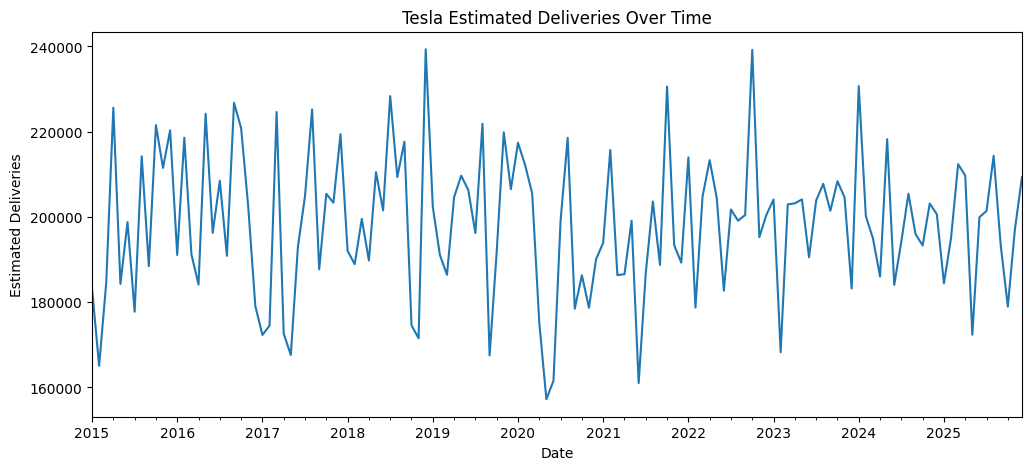

In [11]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

monthly_sales = df.groupby("Date")[
    "Estimated_Deliveries"
].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

# Conclusion

This project successfully developed an end-to-end Machine Learning Pipeline using Tesla EA Deliveries and Production Data (2015–2025).

The workflow included:

- Data collection and loading
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature encoding using Label Encoding
- Model training using Random Forest Regressor
- Model evaluation using R² Score and MAE
- Hyperparameter tuning using GridSearchCV
- Time-series visualization of Tesla deliveries

Results:
- R² Score: 0.9887
- MAE: 323.46

The high R² score indicates that the model captures the relationship between vehicle deliveries and other business variables effectively. The project demonstrates a complete machine learning workflow from raw data to predictive modeling and visualization.